In [20]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os
import pandas as pd

import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

In [21]:
folder = "../build/"
files = glob.glob(
    os.path.join(folder, "*particle_*.csv")
)
print(f"Found {len(files)} files.")

Found 0 files.


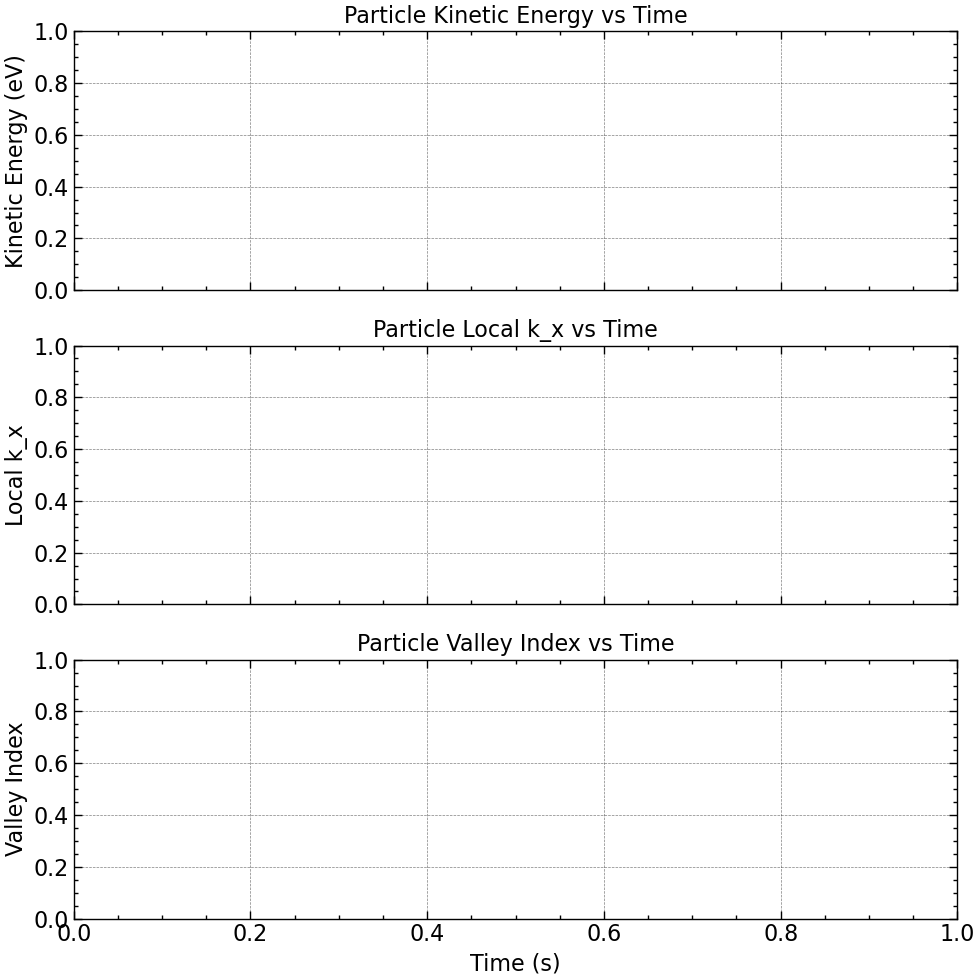

In [22]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for file in files[:2]:
    print(f"Processing file: {file}")
    data = np.loadtxt(file, delimiter=',', skiprows=1)
    time,position_x,position_y,position_z,local_k_x,local_k_y,local_k_z,velocity_x,velocity_y,velocity_z,kinetic_energy,gamma,valley_index = data.T
    print("Nb of time steps:", len(time))
    axs[0].plot(time, kinetic_energy)
    axs[1].plot(time, local_k_x)
    axs[2].plot(time, valley_index)

axs[0].set_ylabel('Kinetic Energy (eV)')
axs[0].set_title('Particle Kinetic Energy vs Time')
axs[1].set_ylabel('Local k_x')
axs[1].set_title('Particle Local k_x vs Time')
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('Valley Index')
axs[2].set_title('Particle Valley Index vs Time')
plt.tight_layout()
plt.show()

Processing file: ../build/observables.csv


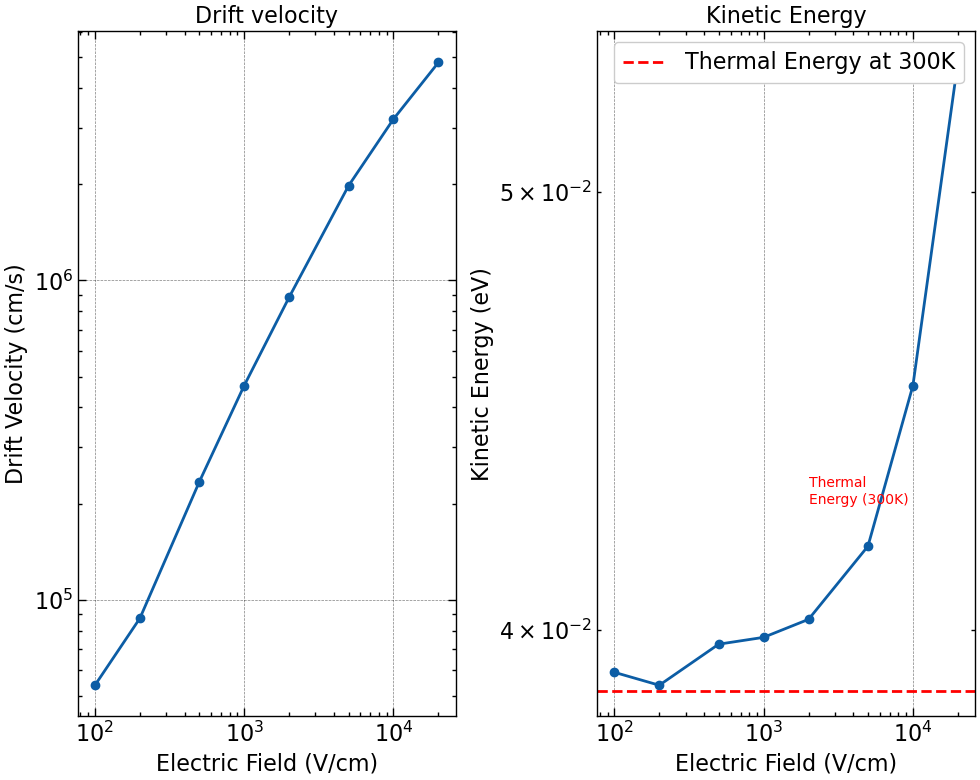

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(10, 8))
file = "../build/observables.csv"
print(f"Processing file: {file}")

m_to_cm = 1e2
electric_field_V_per_m,mean_velocity_x_m_per_s,mean_kinetic_energy_eV,sample_count = np.loadtxt(file, delimiter=',', skiprows=1, unpack=True)
electric_field_V_per_m *= 1.0/m_to_cm  # Convert to V/cm
axs[0].loglog(electric_field_V_per_m, np.abs(mean_velocity_x_m_per_s)*m_to_cm, marker='o')
axs[1].loglog(electric_field_V_per_m, mean_kinetic_energy_eV, marker='o')
axs[0].set_ylabel('Drift Velocity (cm/s)')
axs[0].set_title('Drift velocity')
axs[0].set_xlabel('Electric Field (V/cm)')
axs[1].set_ylabel('Kinetic Energy (eV)')
axs[1].set_title('Kinetic Energy')
axs[1].set_xlabel('Electric Field (V/cm)')

thermal_energy_eV = 1.5 * 1.380649e-23 * 300 / 1.60218e-19
axs[1].axhline(thermal_energy_eV, color='red', linestyle='--', label='Thermal Energy at 300K')
axs[1].text(electric_field_V_per_m[-4], thermal_energy_eV*1.1, 'Thermal \nEnergy (300K)', color='red', fontsize=10)  # Adjust position as needed
axs[1].legend()

plt.tight_layout()
plt.show()

Estimated low-field mobility: 468.03 cm^2/(V·s)


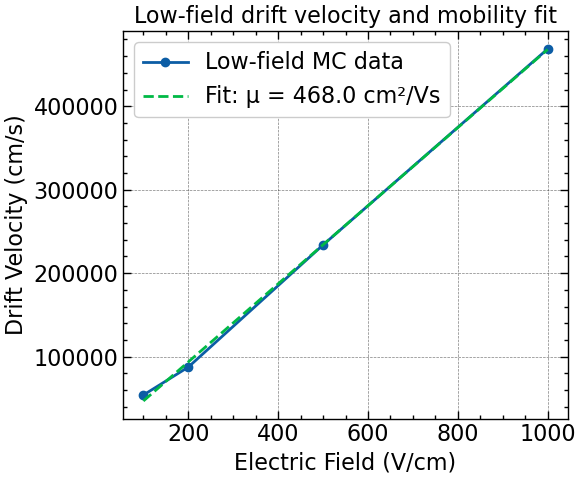

In [24]:
file = "../build/observables.csv"
m_to_cm = 1e2

electric_field_V_per_m, mean_velocity_x_m_per_s, _, _ = np.loadtxt(
    file, delimiter=",", skiprows=1, unpack=True
)

electric_field_V_per_cm = electric_field_V_per_m / m_to_cm
drift_velocity_cm_per_s = np.abs(mean_velocity_x_m_per_s) * m_to_cm

# Keep only low-field points
low_field_max_V_per_cm = 1e3
mask_low = (electric_field_V_per_cm > 0.0) & (electric_field_V_per_cm <= low_field_max_V_per_cm)

E_low = electric_field_V_per_cm[mask_low]
v_low = drift_velocity_cm_per_s[mask_low]

# Linear fit through the origin: v = mu * E
mobility_cm2_per_Vs = np.sum(E_low * v_low) / np.sum(E_low * E_low)

print(f"Estimated low-field mobility: {mobility_cm2_per_Vs:.2f} cm^2/(V·s)")

plt.figure(figsize=(6, 5))
plt.plot(E_low, v_low, "-o", label="Low-field MC data")

E_fit = np.linspace(E_low.min(), E_low.max(), 200)
v_fit = mobility_cm2_per_Vs * E_fit
plt.plot(E_fit, v_fit, "--", label=f"Fit: μ = {mobility_cm2_per_Vs:.1f} cm²/Vs")

plt.xlabel("Electric Field (V/cm)")
plt.ylabel("Drift Velocity (cm/s)")
plt.title("Low-field drift velocity and mobility fit")
plt.legend()
plt.tight_layout()
plt.show()